<h1><center>Watershed Delineation

In [115]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import os
from matplotlib import pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling, calculate_default_transform
from shapely.geometry import shape
from matplotlib.colors import ListedColormap
from pysheds.grid import Grid

In [116]:
# Set the working directory
path = "C:/Users/aksha/Downloads/Final_Project_GIS"
os.chdir(path)

In [117]:
# Step 1: List of DEM files to be used
bilfiles = ['n29_w094_1arc_v3.bil', 'n29_w095_1arc_v3.bil', 'n30_w094_1arc_v3.bil', 'n30_w095_1arc_v3.bil']

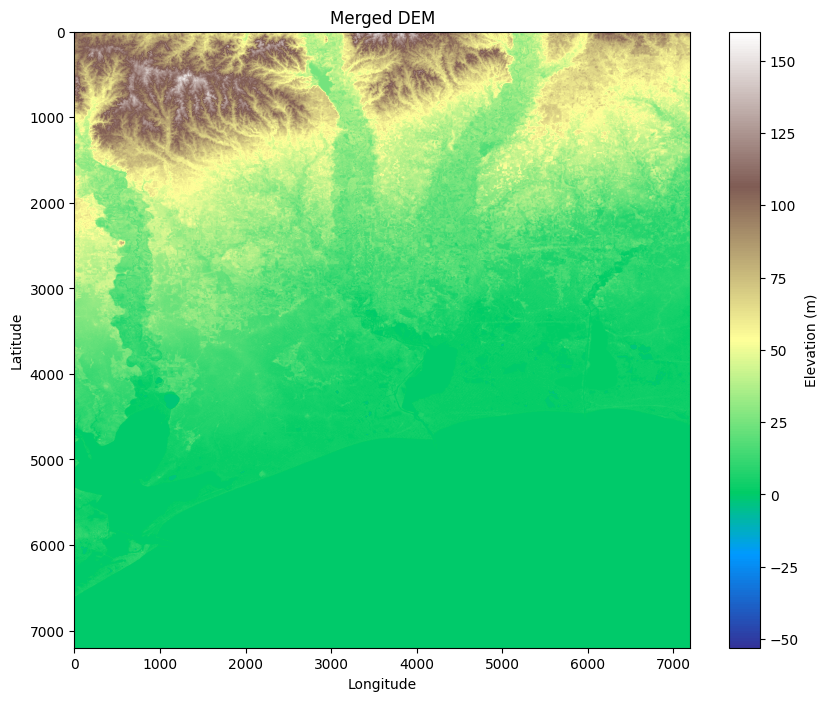

In [118]:
# Step 2: Open and merge DEM files
datasets = [rasterio.open(file) for file in bilfiles]
mosaic, out_transform = merge(datasets)
out_meta = datasets[0].meta.copy()
out_meta.update({
    'driver': 'GTiff',
    'height': mosaic.shape[1],
    'width': mosaic.shape[2],
    'transform': out_transform
})
with rasterio.open('merged_dem.tif', 'w', **out_meta) as dest:
    dest.write(mosaic)
for dataset in datasets:
    dataset.close()
    # Plot merged DEM
plt.figure(figsize=(10, 8))
plt.imshow(mosaic[0], cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.title('Merged DEM')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Clipped DEM saved as 'clipped_dem_orange.tif'.


C:\Users\aksha\AppData\Local\Temp\ipykernel_17776\1975865229.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geo_union = gdf.geometry.unary_union


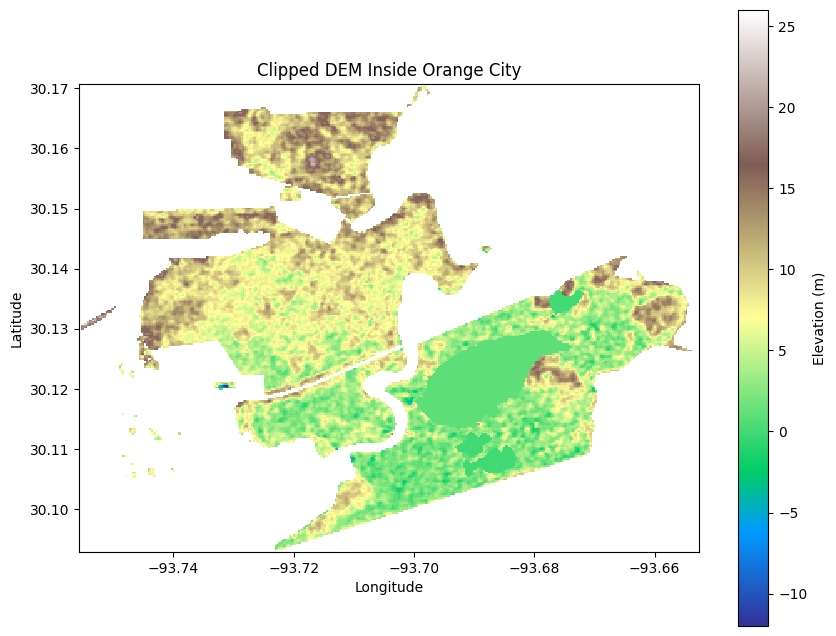

In [122]:
# Step 3: Clip the DEM to the city boundary
gdf = gpd.read_file('ORANGE_CITY.gpkg')

geo_union = gdf.geometry.unary_union

with rasterio.open('merged_dem.tif') as src:
    # Apply mask to the DEM using the city boundary
    out_image, out_transform = mask(src, [geo_union], crop=True, nodata=-9999)
    
    # Copy the metadata from the DEM and update it for the new clipped image
    out_meta = src.profile.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
        "nodata": -9999
    })

with rasterio.open('clipped_dem_orange.tif', 'w', **out_meta) as dest:
    dest.write(out_image)

print("Clipped DEM saved as 'clipped_dem_orange.tif'.")
#Plotting
data = out_image[0] 
data_masked = np.where(data == -9999, np.nan, data) 
terrain_cmap = plt.cm.terrain(np.linspace(0, 1, 256))  
terrain_cmap[0, :] = [1, 1, 1, 1] 
custom_cmap = ListedColormap(terrain_cmap)
min_x, min_y = out_transform * (0, data.shape[0])  
max_x, max_y = out_transform * (data.shape[1], 0)  

# Plot with extent for geospatial axes
plt.figure(figsize=(10, 8))
plt.imshow(data_masked, cmap='terrain', extent=(min_x, max_x, min_y, max_y), interpolation="none")
plt.colorbar(label='Elevation (m)')
plt.title('Clipped DEM Inside Orange City')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [107]:
# Step 4: Identify the lowest elevation point in the city
with rasterio.open('clipped_dem_orange.tif') as src:
    data = src.read(1)
    transform = src.transform
masked_data = np.ma.masked_equal(data, -9999)
row, col = np.unravel_index(np.argmin(masked_data), data.shape)
lowest_point_coords = rasterio.transform.xy(transform, row, col, offset='center')
print(f"Lowest elevation point coordinates: {lowest_point_coords}")

Lowest elevation point coordinates: (-93.73138888888889, 30.120555555555555)


In [128]:
# Step 5: Condition the DEM for flow analysis
grid = Grid.from_raster('clipped_dem_orange.tif')
dem = grid.read_raster('clipped_dem_orange.tif')
pit_filled_dem = grid.fill_pits(dem)
flooded_dem = grid.fill_depressions(pit_filled_dem)
inflated_dem = grid.resolve_flats(flooded_dem)


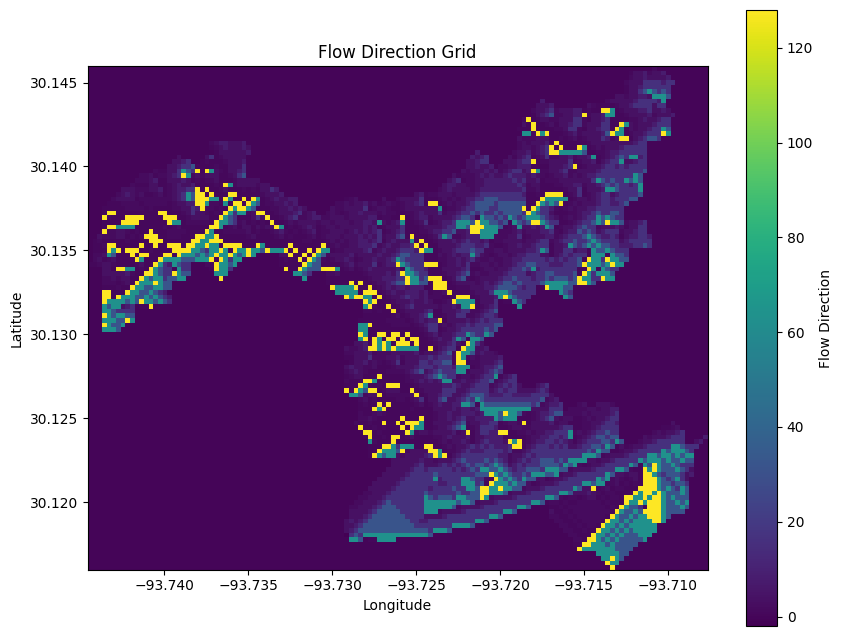

In [130]:
# Step 6: Calculate flow direction
fdir = grid.flowdir(inflated_dem, dirmap=(64, 128, 1, 2, 4, 8, 16, 32))

# Plot flow direction
plt.figure(figsize=(10, 8))
plt.imshow(fdir, cmap='viridis', extent=grid.extent)
plt.colorbar(label='Flow Direction')
plt.title('Flow Direction Grid')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [132]:
# Step 7: Calculate flow accumulation
acc = grid.accumulation(fdir)

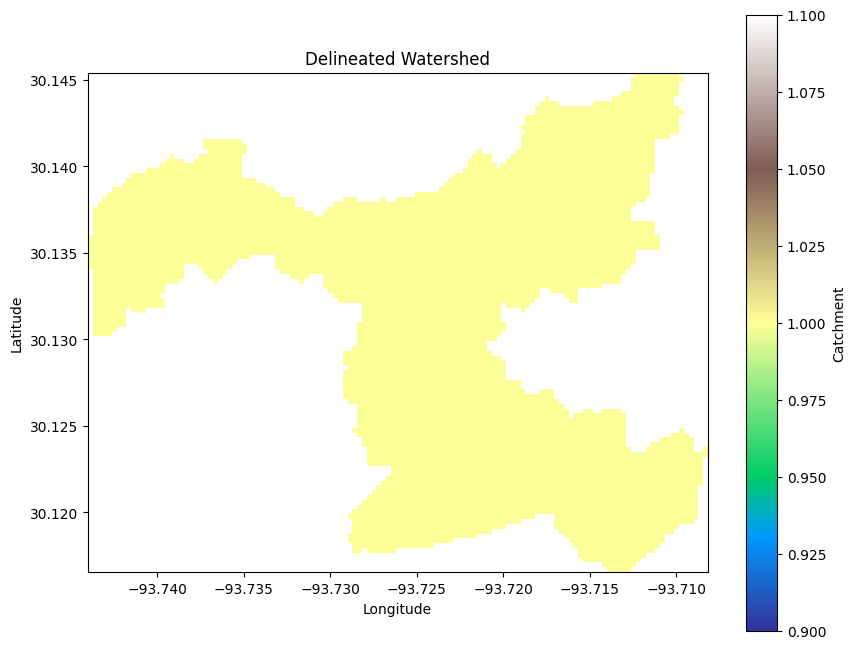

In [134]:
# Step 8: Delineate the watershed
x, y = lowest_point_coords
x_snap, y_snap = grid.snap_to_mask(acc > 1000, (x, y))
catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, dirmap=(64, 128, 1, 2, 4, 8, 16, 32), xytype='coordinate')
grid.clip_to(catch)
clipped_catch = grid.view(catch)

# Plot delineated watershed
plt.figure(figsize=(10, 8))
plt.imshow(np.where(clipped_catch, clipped_catch, np.nan), cmap='terrain', extent=grid.extent)
plt.colorbar(label='Catchment')
plt.title('Delineated Watershed')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [135]:

# Step 9: Reproject for area calculation
aea_epsg = 5070
with rasterio.open('clipped_dem_orange.tif') as src:
    transform, width, height = calculate_default_transform(src.crs, aea_epsg, src.width, src.height, *src.bounds)
    reprojected_raster = 'reprojected_clipped_dem.tif'
    with rasterio.open(reprojected_raster, 'w', driver='GTiff', height=height, width=width, count=1, dtype='float32', crs=aea_epsg, transform=transform) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=aea_epsg,
            resampling=Resampling.nearest
        )

In [136]:
# Step 10: Compute watershed area
with rasterio.open(reprojected_raster) as reprojected_src:
    catchment_data = reprojected_src.read(1)
    mask = catchment_data > 0
    polygons = [shape(geom) for geom, value in rasterio.features.shapes(catchment_data, mask=mask, transform=reprojected_src.transform) if value > 0]
    catchment_polygon = polygons[0] if len(polygons) == 1 else ops.unary_union(polygons)
    area_sq_meters = catchment_polygon.area
    area_sq_km = area_sq_meters / 1_000_000
    print(f"Watershed Area: {area_sq_km:.2f} km²")

Watershed Area: 30.25 km²


In [137]:
# Save the watershed polygon
gdf_out = gpd.GeoDataFrame(geometry=[catchment_polygon])
gdf_out.set_crs(aea_epsg, inplace=True)
gdf_out.to_file('delineated_catchment.shp')